# Bankruptcy Prevention

### 1. Importing the required Libraries

In [29]:
# importing the libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import chi2_contingency
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report, precision_score, recall_score, roc_auc_score, roc_curve
from sklearn.svm import SVC

In [4]:
df = pd.read_excel('bankruptcy-prevention (1).xlsx')
df = df.iloc[:, 0].str.split(';', expand=True)
df.columns = [
    "industrial_risk",
    "management_risk",
    "financial_flexibility",
    "credibility",
    "competitiveness",
    "operating_risk",
    "class"
]
df.head()

,industrial_risk,management_risk,financial_flexibility,credibility,competitiveness,operating_risk,class
0,0.5,1,0,0,0,0.5,bankruptcy
1,0,1,0,0,0,1,bankruptcy
2,1,0,0,0,0,1,bankruptcy
3,0.5,0,0,0.5,0,1,bankruptcy
4,1,1,0,0,0,1,bankruptcy


### 2. Exploratory Data Analysis

In [5]:
#converting columns in float except class
for col in df.columns[:-1]:
  df[col] = df[col].astype(float)

df['class'] = df['class'].astype(str)

In [6]:
df.shape

(250, 7)

In [7]:
df.describe()

,industrial_risk,management_risk,financial_flexibility,credibility,competitiveness,operating_risk
count,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000
mean,0.518000,0.614000,0.376000,0.470000,0.476000,0.570000
std,0.411526,0.410705,0.401583,0.415682,0.440682,0.434575
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.500000,0.000000,0.000000,0.000000,0.000000
50%,0.500000,0.500000,0.500000,0.500000,0.500000,0.500000
75%,1.000000,1.000000,0.500000,1.000000,1.000000,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   industrial_risk        250 non-null    float64
 1   management_risk        250 non-null    float64
 2   financial_flexibility  250 non-null    float64
 3   credibility            250 non-null    float64
 4   competitiveness        250 non-null    float64
 5   operating_risk         250 non-null    float64
 6   class                  250 non-null    object 
dtypes: float64(6), object(1)
memory usage: 13.8+ KB


In [9]:
#Encoding the class column
df['class'] = df['class'].map({ 'bankruptcy' : 1, 'non-bankruptcy': 0})

In [10]:
#checking for missing values
df.isnull().sum()

,0
industrial_risk,0
management_risk,0
financial_flexibility,0
credibility,0
competitiveness,0
operating_risk,0
class,0


class
0    143
1    107
Name: count, dtype: int64


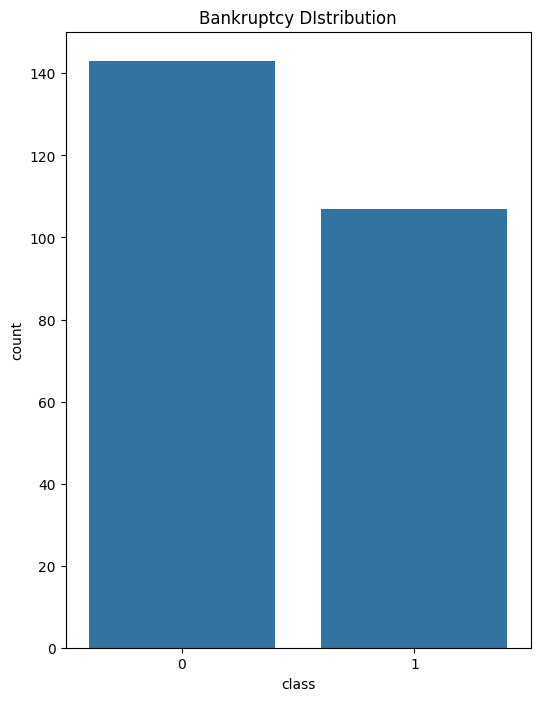

In [11]:
# Target Distribution
print(df['class'].value_counts())

plt.figure(figsize=(6,8))
sns.countplot(x='class', data=df)
plt.title('Bankruptcy DIstribution')
plt.show()

<Figure size 1200x800 with 0 Axes>

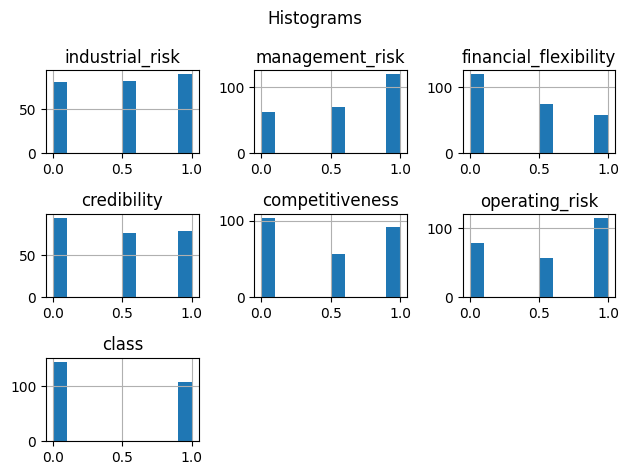

In [12]:
#histograms
plt.figure(figsize=(12,8))
df.hist()
plt.suptitle('Histograms')
plt.tight_layout()
plt.show()

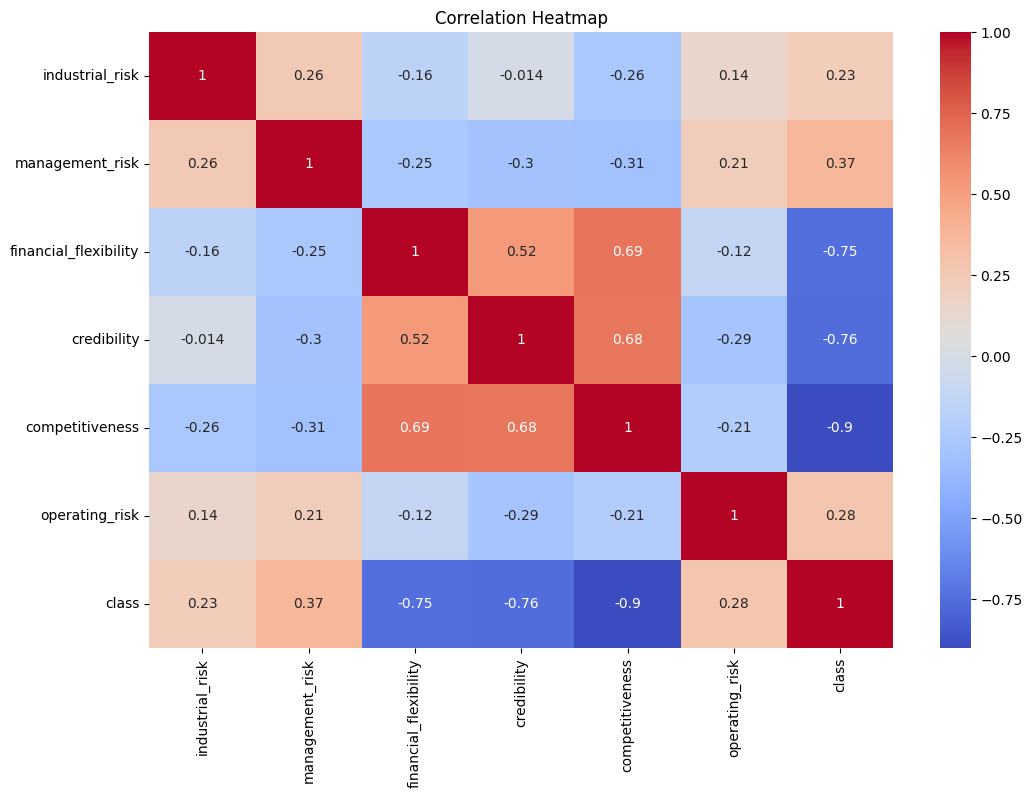

In [13]:
#correlation heatmap
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()


Bankruptcy Rate by industrial_risk
industrial_risk
0.0    32.500000
0.5    34.567901
1.0    59.550562
Name: class, dtype: float64


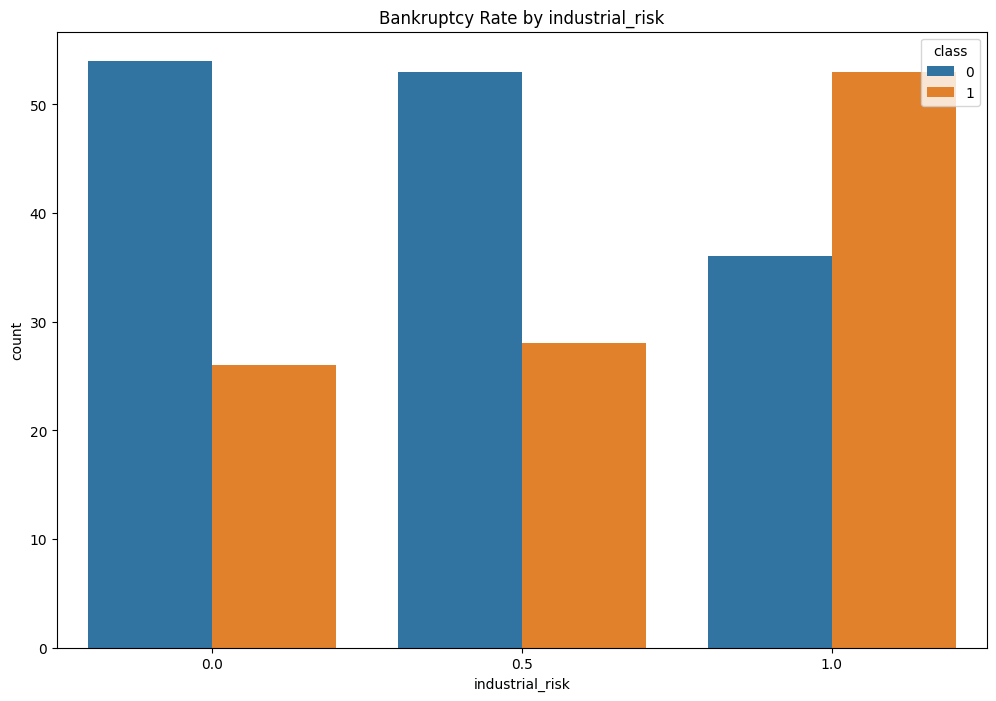


Bankruptcy Rate by management_risk
management_risk
0.0    17.741935
0.5    33.333333
1.0    61.344538
Name: class, dtype: float64


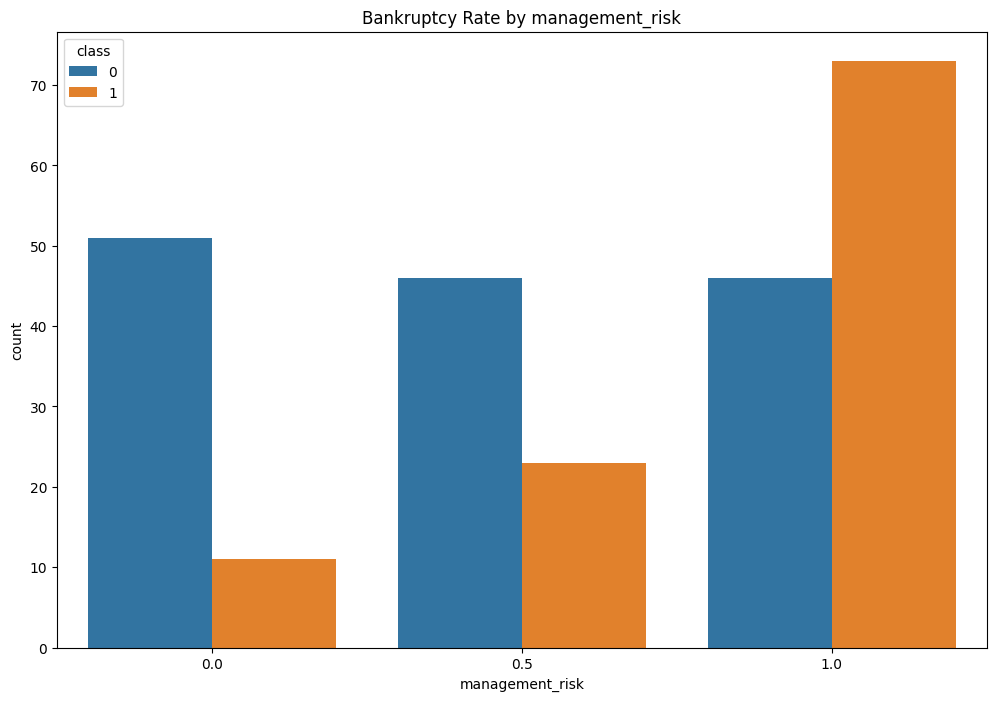


Bankruptcy Rate by financial_flexibility
financial_flexibility
0.0    85.714286
0.5     5.405405
1.0     1.754386
Name: class, dtype: float64


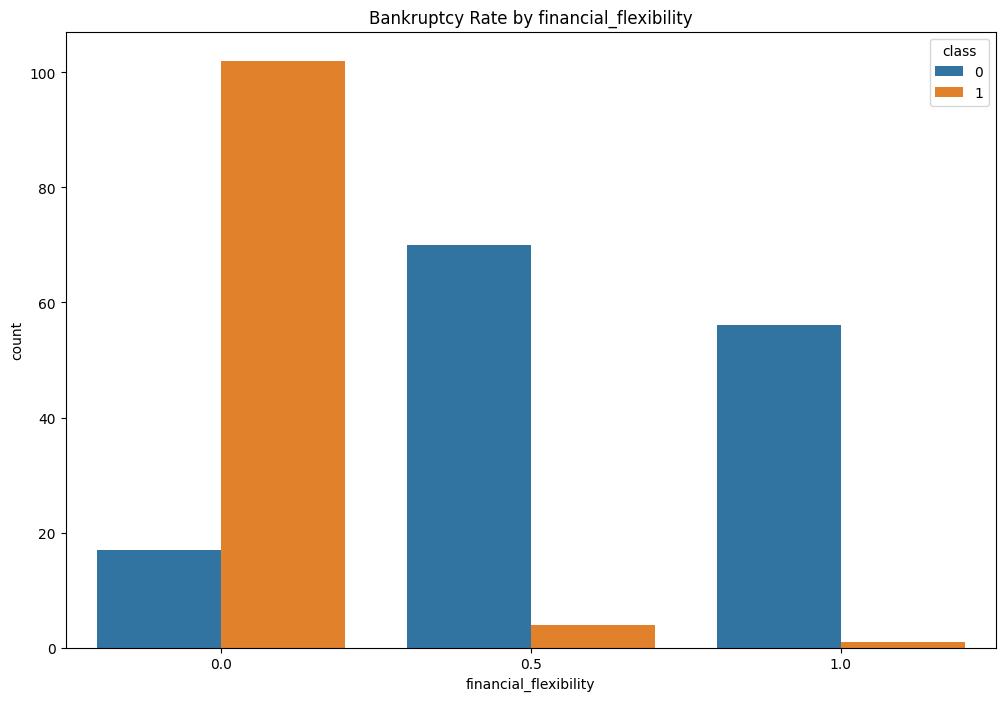


Bankruptcy Rate by credibility
credibility
0.0    92.553191
0.5    22.077922
1.0     3.797468
Name: class, dtype: float64


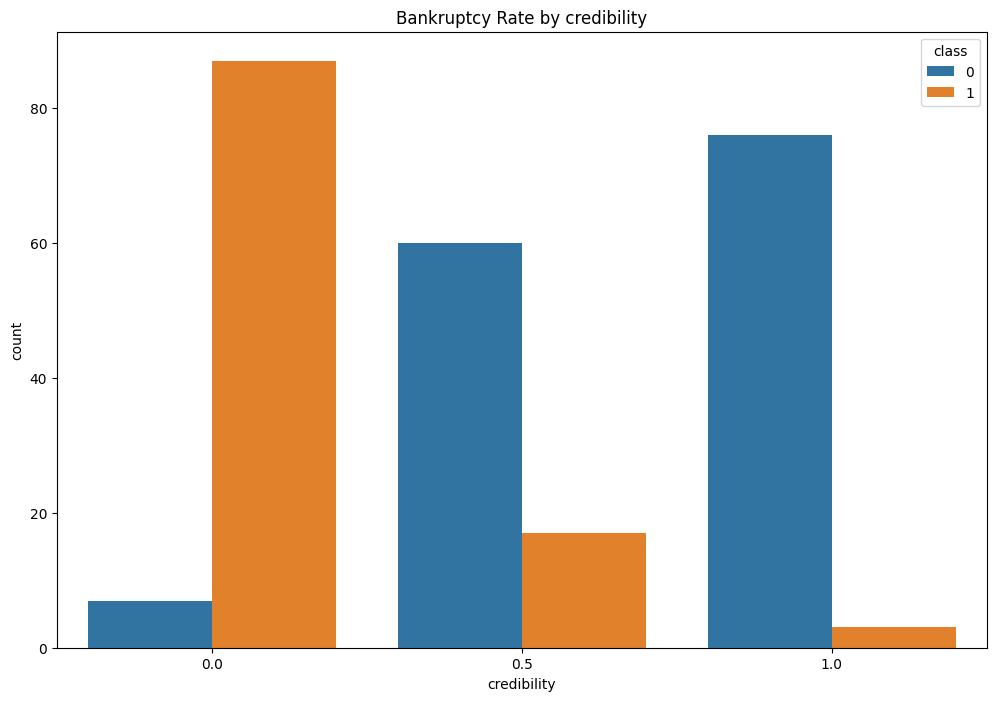


Bankruptcy Rate by competitiveness
competitiveness
0.0    100.000000
0.5      7.142857
1.0      0.000000
Name: class, dtype: float64


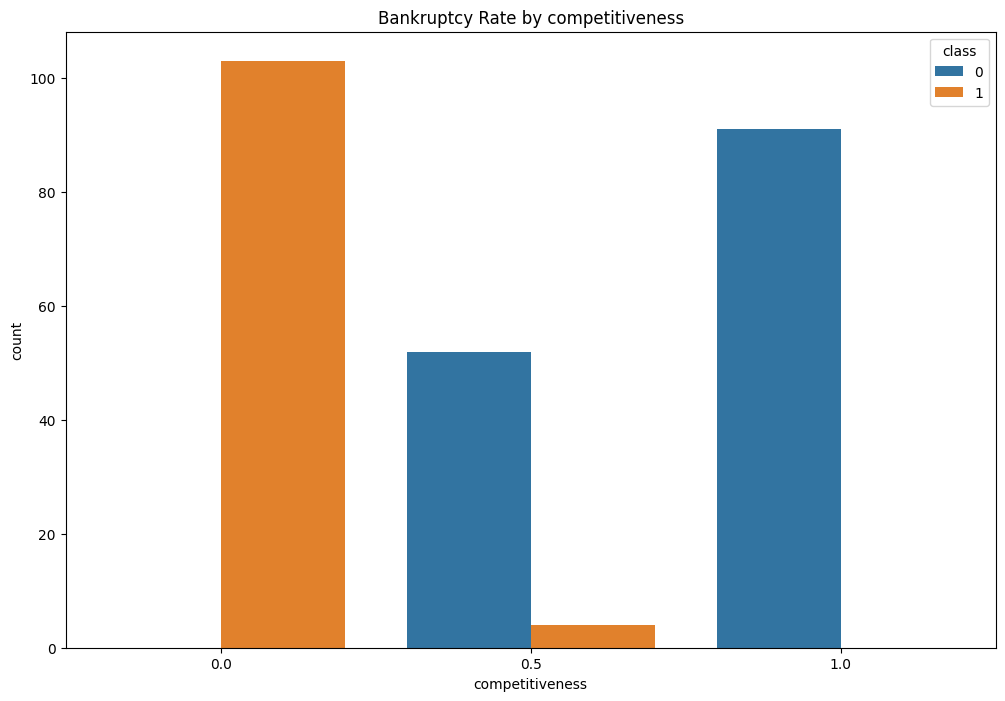


Bankruptcy Rate by operating_risk
operating_risk
0.0    24.050633
0.5    42.105263
1.0    56.140351
Name: class, dtype: float64


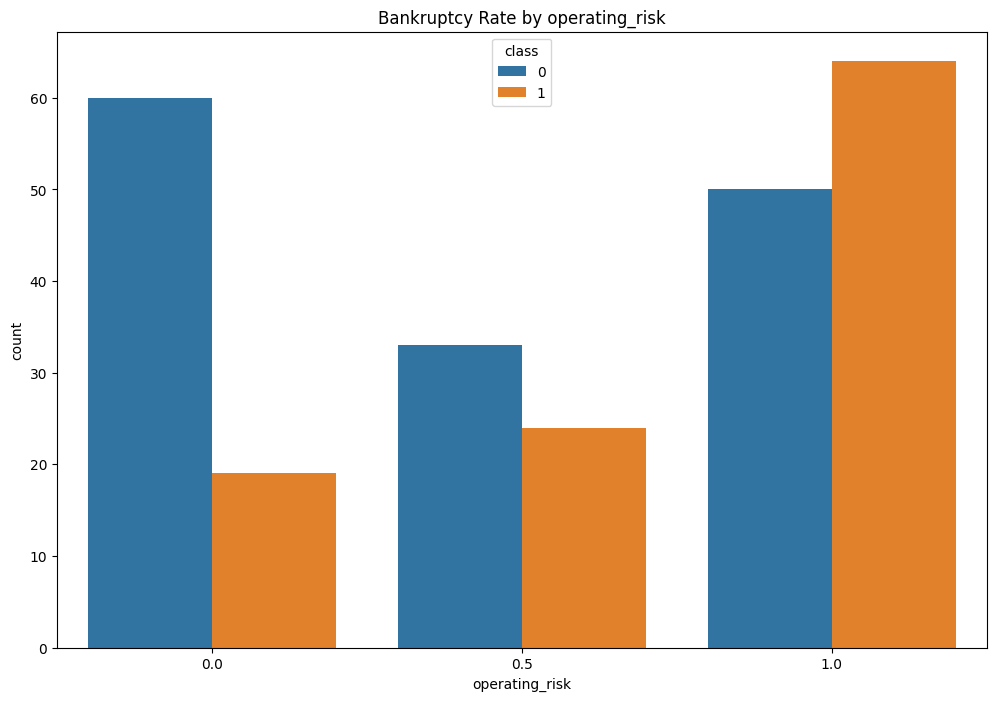

In [14]:
#Feature vs Target
for col in df.columns[:-1]:
  print(f"\nBankruptcy Rate by {col}")
  print(df.groupby(col)['class'].mean()*100)

  plt.figure(figsize=(12,8))
  sns.countplot(x=col, hue='class', data=df)
  plt.title(f'Bankruptcy Rate by {col}')
  plt.show()

Here from the graphs we can observe the relation between each feature and the target column class means as the competitiveness increases the bankruptcy rate decreases etc for all the features.

In [15]:
# chi-square test for confirming statistically significant association
for col in df.columns[:-1]:
  table = pd.crosstab(df[col], df['class'])
  stat, p, dof, expected = chi2_contingency(table)
  print(f"\nFeature: {col}")
  print("Chi-Square:", stat)
  print("P-value:", p)

  if p < 0.05:
    print("Association is statistically significant")
  else:
    print("No Significant Association")


Feature: industrial_risk
Chi-Square: 15.909132158388347
P-value: 0.00035105555200737033
Association is statistically significant

Feature: management_risk
Chi-Square: 35.14391287715872
P-value: 2.3366640799655196e-08
Association is statistically significant

Feature: financial_flexibility
Chi-Square: 171.0114187979412
P-value: 7.334022479873933e-38
Association is statistically significant

Feature: credibility
Chi-Square: 157.63858326099742
P-value: 5.877823993543991e-35
Association is statistically significant

Feature: competitiveness
Chi-Square: 234.82825585629325
P-value: 1.0178695989095595e-51
Association is statistically significant

Feature: operating_risk
Chi-Square: 19.642131120771523
P-value: 5.429569801610118e-05
Association is statistically significant


Here from the above results the higher the chisquare value the higher the significance with the class variable i.e the most important feature with highest chi-sqaure value is competitiveness which value is 234 etc..

### 3. Model Building

In [16]:
# splitting the data into training and testing set
X = df.drop('class', axis=1)
y=df['class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [17]:
# Scaling the data for only Logistic and SVM Models as it is important for both models
scaler = StandardScaler()
X_train_Scaled = scaler.fit_transform(X_train)
X_test_Scaled = scaler.transform(X_test)

In [18]:
# Evaluation Function for each model
def evaluation_model(model, X_test, y_test):
  y_pred = model.predict(X_test)
  y_prob = model.predict_proba(X_test)[:,1]

  print("Accuracy:", accuracy_score(y_test, y_pred))
  print("Precision:", precision_score(y_test, y_pred))
  print("Recall:", recall_score(y_test, y_pred))
  print("F1 Score:", f1_score(y_test, y_pred))
  print("ROC-AUC:", roc_auc_score(y_test, y_prob))

  print("\n Confusion Matrix:")
  print(confusion_matrix(y_test, y_pred))

  print("\n Classification Report:")
  print(classification_report(y_test, y_pred))

##### Model-1: Logistic Regression

In [19]:
param_grid_log = {
    'C' : [0.01, 0.1, 1, 10],
    'solver' : ['liblinear']
}

grid_log = GridSearchCV(
    LogisticRegression(),
    param_grid_log,
    cv=5,
    n_jobs=-1,
    scoring='recall'
)

grid_log.fit(X_train_Scaled, y_train)

best_log = grid_log.best_estimator_

print("Best Logistic Parameters:", grid_log.best_params_)
evaluation_model(best_log, X_test_Scaled, y_test)

Best Logistic Parameters: {'C': 0.01, 'solver': 'liblinear'}
Accuracy: 0.96
Precision: 0.9130434782608695
Recall: 1.0
F1 Score: 0.9545454545454546
ROC-AUC: 1.0

 Confusion Matrix:
[[27  2]
 [ 0 21]]

 Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.93      0.96        29
           1       0.91      1.00      0.95        21

    accuracy                           0.96        50
   macro avg       0.96      0.97      0.96        50
weighted avg       0.96      0.96      0.96        50



##### Model-2: Decision Tree

In [20]:
param_grid_dt = {
    'max_depth' : [None, 3, 5, 10],
    'min_samples_split' : [2, 5, 10],
    'criterion' : ['gini', 'entropy']
}

grid_dt = GridSearchCV(
    DecisionTreeClassifier(),
    param_grid_dt,
    cv=5,
    n_jobs=-1,
    scoring='recall'
)

grid_dt.fit(X_train, y_train)

best_dt = grid_dt.best_estimator_

print("Best Decision Tree Parameters:", grid_dt.best_params_)
evaluation_model(best_dt, X_test, y_test)

Best Decision Tree Parameters: {'criterion': 'gini', 'max_depth': None, 'min_samples_split': 2}
Accuracy: 0.98
Precision: 0.9545454545454546
Recall: 1.0
F1 Score: 0.9767441860465116
ROC-AUC: 0.9827586206896552

 Confusion Matrix:
[[28  1]
 [ 0 21]]

 Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.97      0.98        29
           1       0.95      1.00      0.98        21

    accuracy                           0.98        50
   macro avg       0.98      0.98      0.98        50
weighted avg       0.98      0.98      0.98        50



##### Model-3: RandomForest

In [21]:
param_grid_rf = {
    'n_estimators' : [100,200],
    'max_depth' : [None, 5, 10],
    'min_samples_split' : [2, 5, 10]
}

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid_rf,
    cv=5,
    n_jobs=-1,
    scoring='recall'
)

grid_rf.fit(X_train, y_train)
best_rf = grid_rf.best_estimator_

print("Best RandomForest Params:", grid_rf.best_params_)
evaluation_model(best_rf, X_test, y_test)

Best RandomForest Params: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0
ROC-AUC: 1.0

 Confusion Matrix:
[[29  0]
 [ 0 21]]

 Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        29
           1       1.00      1.00      1.00        21

    accuracy                           1.00        50
   macro avg       1.00      1.00      1.00        50
weighted avg       1.00      1.00      1.00        50



##### Model-4: Support Vector Machine

In [22]:
param_grid_svm = {
    'C' : [0.1, 1, 10],
    'kernel' : ['linear', 'rbf']
}

grid_svm = GridSearchCV(
    SVC(probability=True),
    param_grid_svm,
    cv=5,
    n_jobs=-1,
    scoring='recall'
)

grid_svm.fit(X_train_Scaled, y_train)
best_svm = grid_svm.best_estimator_

print("Best SVM Parameters:", grid_svm.best_params_)
evaluation_model(best_svm, X_test_Scaled, y_test)

Best SVM Parameters: {'C': 0.1, 'kernel': 'linear'}
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0
ROC-AUC: 1.0

 Confusion Matrix:
[[29  0]
 [ 0 21]]

 Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        29
           1       1.00      1.00      1.00        21

    accuracy                           1.00        50
   macro avg       1.00      1.00      1.00        50
weighted avg       1.00      1.00      1.00        50



In [23]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(best_rf, X, y, cv=5, scoring='accuracy')
print('Cross Validation Accuracy:', scores.mean())

Cross Validation Accuracy: 0.9960000000000001


In [24]:
#Model Comparison Table
models = {
    "Logistic": best_log,
    "Decision Tree": best_dt,
    "Random Forest": best_rf,
    "SVM": best_svm
}

results = []

for name, model in models.items():
  if name in ['Logistic', 'SVM']:
    X_eval = X_test_Scaled
  else:
    X_eval = X_test

  y_pred = model.predict(X_eval)
  y_prob = model.predict_proba(X_eval)[:,1]

  results.append([
        name,
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred),
        recall_score(y_test, y_pred),
        f1_score(y_test, y_pred),
        roc_auc_score(y_test, y_prob)
    ])
results_df = pd.DataFrame(results, columns=['Model', 'Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC'])
results_df.sort_values(by='Recall', ascending=False)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic,0.96,0.913043,1.0,0.954545,1.000000
1,Decision Tree,0.98,0.954545,1.0,0.976744,0.982759
2,Random Forest,1.00,1.000000,1.0,1.000000,1.000000
3,SVM,1.00,1.000000,1.0,1.000000,1.000000


In [25]:
#Feature Importance - For Random Forest
importance_df = pd.DataFrame({
    'Feature' : X.columns,
    'Importance' : best_rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

importance_df

,Feature,Importance
4,competitiveness,0.485679
2,financial_flexibility,0.221955
3,credibility,0.215781
1,management_risk,0.036441
0,industrial_risk,0.026195
5,operating_risk,0.013949


In this project, four classification models were implemented to predict corporate bankruptcy:

Logistic Regression

Decision Tree

Random Forest

Support Vector Machine (SVM)

The objective was to compare linear, non-linear, tree-based, and margin-based approaches to determine which model best captures bankruptcy risk patterns.

All models achieved very high performance:

Accuracy ≥ 96%

Recall = 100% for bankruptcy class

Cross-validation accuracy ≈ 99.6%

Random Forest and SVM achieved perfect classification on the test set.

The consistently high performance across all models indicates:

Strong separability between bankrupt and non-bankrupt firms

Highly informative risk features

Low noise in dataset

Clear monotonic relationship between risk and bankruptcy

Even the linear model (Logistic Regression) performed extremely well, which suggests that the decision boundary is almost linearly separable.

Tree-based and margin-based models further captured small non-linearities, leading to near-perfect classification.

Random Forest was selected as the final model for its robustness and feature importance capability.

In [26]:
import joblib
joblib.dump(best_rf, 'Bankruptcy_model.pkl')

['Bankruptcy_model.pkl']

In [32]:
print(f"Matplotlib version: {plt.matplotlib.__version__}")
print(f"Seaborn version: {sns.__version__}")

Matplotlib version: 3.10.0
Seaborn version: 0.13.2
